# Proyecto Métodos Heurísticos (Montecarlo)

## Predicción de potencia entregada con relación a la resistencia inducida de una celda Peltier

### Objetivos

#### Objetivo General

#### Objetivos Específicos

### Ejecución

Importamos las librerías necesarias. En este caso serán `pandas`, `numpy` y `matplotlib`.

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Importamos el archivo con los datos del archivo csv y usamos guardamos solo los datos que trataremos.

In [ ]:
peltierData = pd.read_csv("peltier-P-R.csv")

peltierData = peltierData.drop(columns=["I", "Voltage", "Temperature"])

Definimos un arreglo con el cambio porcentual.

In [ ]:
percentualChangeInPower = (
    peltierData.pct_change().dropna()
)  # Calcula el cambio porcentual de la potencia

Definimos los parametros de la simulación.

In [ ]:
nResistences = 50
nSimulations = 100000

resistances = np.linspace(
    (peltierData["Resistance"]).max() + 2,
    (peltierData["Resistance"]).max() + 100,
    nResistences,
)  # 50 resistencias entre 102 ohms y 200 ohms

Se ejecutan las simulaciones, con el número de simulaciones definido.

In [ ]:
simulatedPower = pd.DataFrame(
    np.random.normal(
        percentualChangeInPower["Power"].mean(),
        percentualChangeInPower["Power"].std(),
        size=(nResistences, nSimulations),
    ),
    resistances,
)  # Simula la potencia con una distribución normal

Se filtran los datos, obteniendo así el porcentaje de casos en que la potencia es 10% mayor.

In [ ]:
filteredData = (
    peltierData.iloc[-1, 0] * (simulatedPower + 1).cumprod(axis=0)
    > peltierData.iloc[-1, 0] * 1.1
).mean(
    axis=1
)  # Filtra los datos que cumplen la condición de potencia > 10%

Por último se grafican los datos.

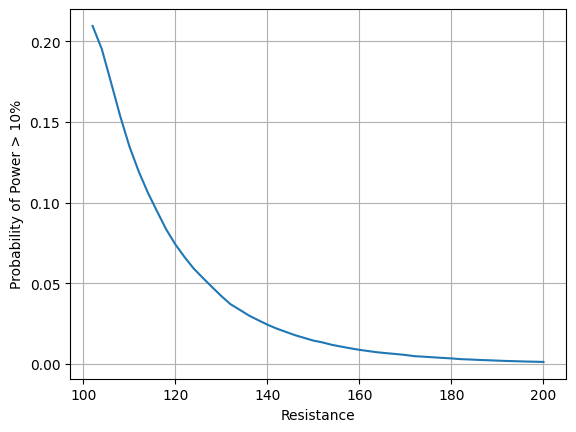

In [ ]:
filteredData.plot(grid=True)
plt.xlabel("Resistance")
plt.ylabel("Probability of Power > 10%")
plt.show()